Example notebook demonstrating the use of prior-transformed log-likelihood in `pyvela`. 

In [1]:
from pyvela import SPNTA, pyvela_plot
from pyvela.sampling import run_emcee_until_converged
import emcee
import numpy as np
import shutil
import os
import corner

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
spnta = SPNTA(
    parfile="NGC6440E.par",
    timfile="NGC6440E.tim",
    cheat_prior_scale=100,
)

WARNING  (pint.toa                      ): No pulse numbers for TOAs
WARNING  (pint.toa                      ): No pulse numbers for TOAs


In [3]:
spnta.model.pulsar_name

'J1748-2021E'

In [4]:
# Create the output directory and save the pre-analysis summary
result_dir = "NGC6440E_out"
if os.path.isdir(result_dir):
    shutil.rmtree(result_dir)
os.mkdir(result_dir)

spnta.save_pre_analysis_summary(result_dir)

In [5]:
nwalkers = spnta.ndim * 5

# We are doing the sampling within an ndim-dimensional unit hypercube.
p0 = np.random.rand(nwalkers, spnta.ndim) 

In [6]:
# SPNTA.lnpost_transformed_vectorized() acts within a unit hypercube.
sampler = emcee.EnsembleSampler(
    nwalkers, spnta.ndim, spnta.lnpost_transformed_vectorized, vectorize=True
)

In [7]:
converged, tau = run_emcee_until_converged(
    sampler, 
    p0, 
    initial_chunk=2000, 
    min_chunk=500, 
    tau_multiplier=30
)

100%|██████████| 2000/2000 [00:01<00:00, 1323.39it/s]


N =   2000 | tau_max =    86.71 | N/tau =    23.1 | long = False | stable = False | 


100%|██████████| 500/500 [00:00<00:00, 1524.56it/s]


N =   2500 | tau_max =    96.32 | N/tau =    26.0 | long = False | stable = False | 


100%|██████████| 500/500 [00:00<00:00, 1471.19it/s]


...

N =   6500 | tau_max =   130.44 | N/tau =    49.8 | long = True | stable = False | 


100%|██████████| 500/500 [00:00<00:00, 1439.85it/s]


N =   7000 | tau_max =   132.66 | N/tau =    52.8 | long = True | stable = True | 


100%|██████████| 500/500 [00:00<00:00, 1364.49it/s]


N =   7500 | tau_max =   133.59 | N/tau =    56.1 | long = True | stable = True | 
Converged.


In [8]:
samples_raw_untr = sampler.get_chain(flat=True, discard=int(max(tau))*50, thin=50)

# Undo the transformation.
samples_raw = spnta.prior_transform(samples_raw_untr)
samples = spnta.rescale_samples(samples_raw)

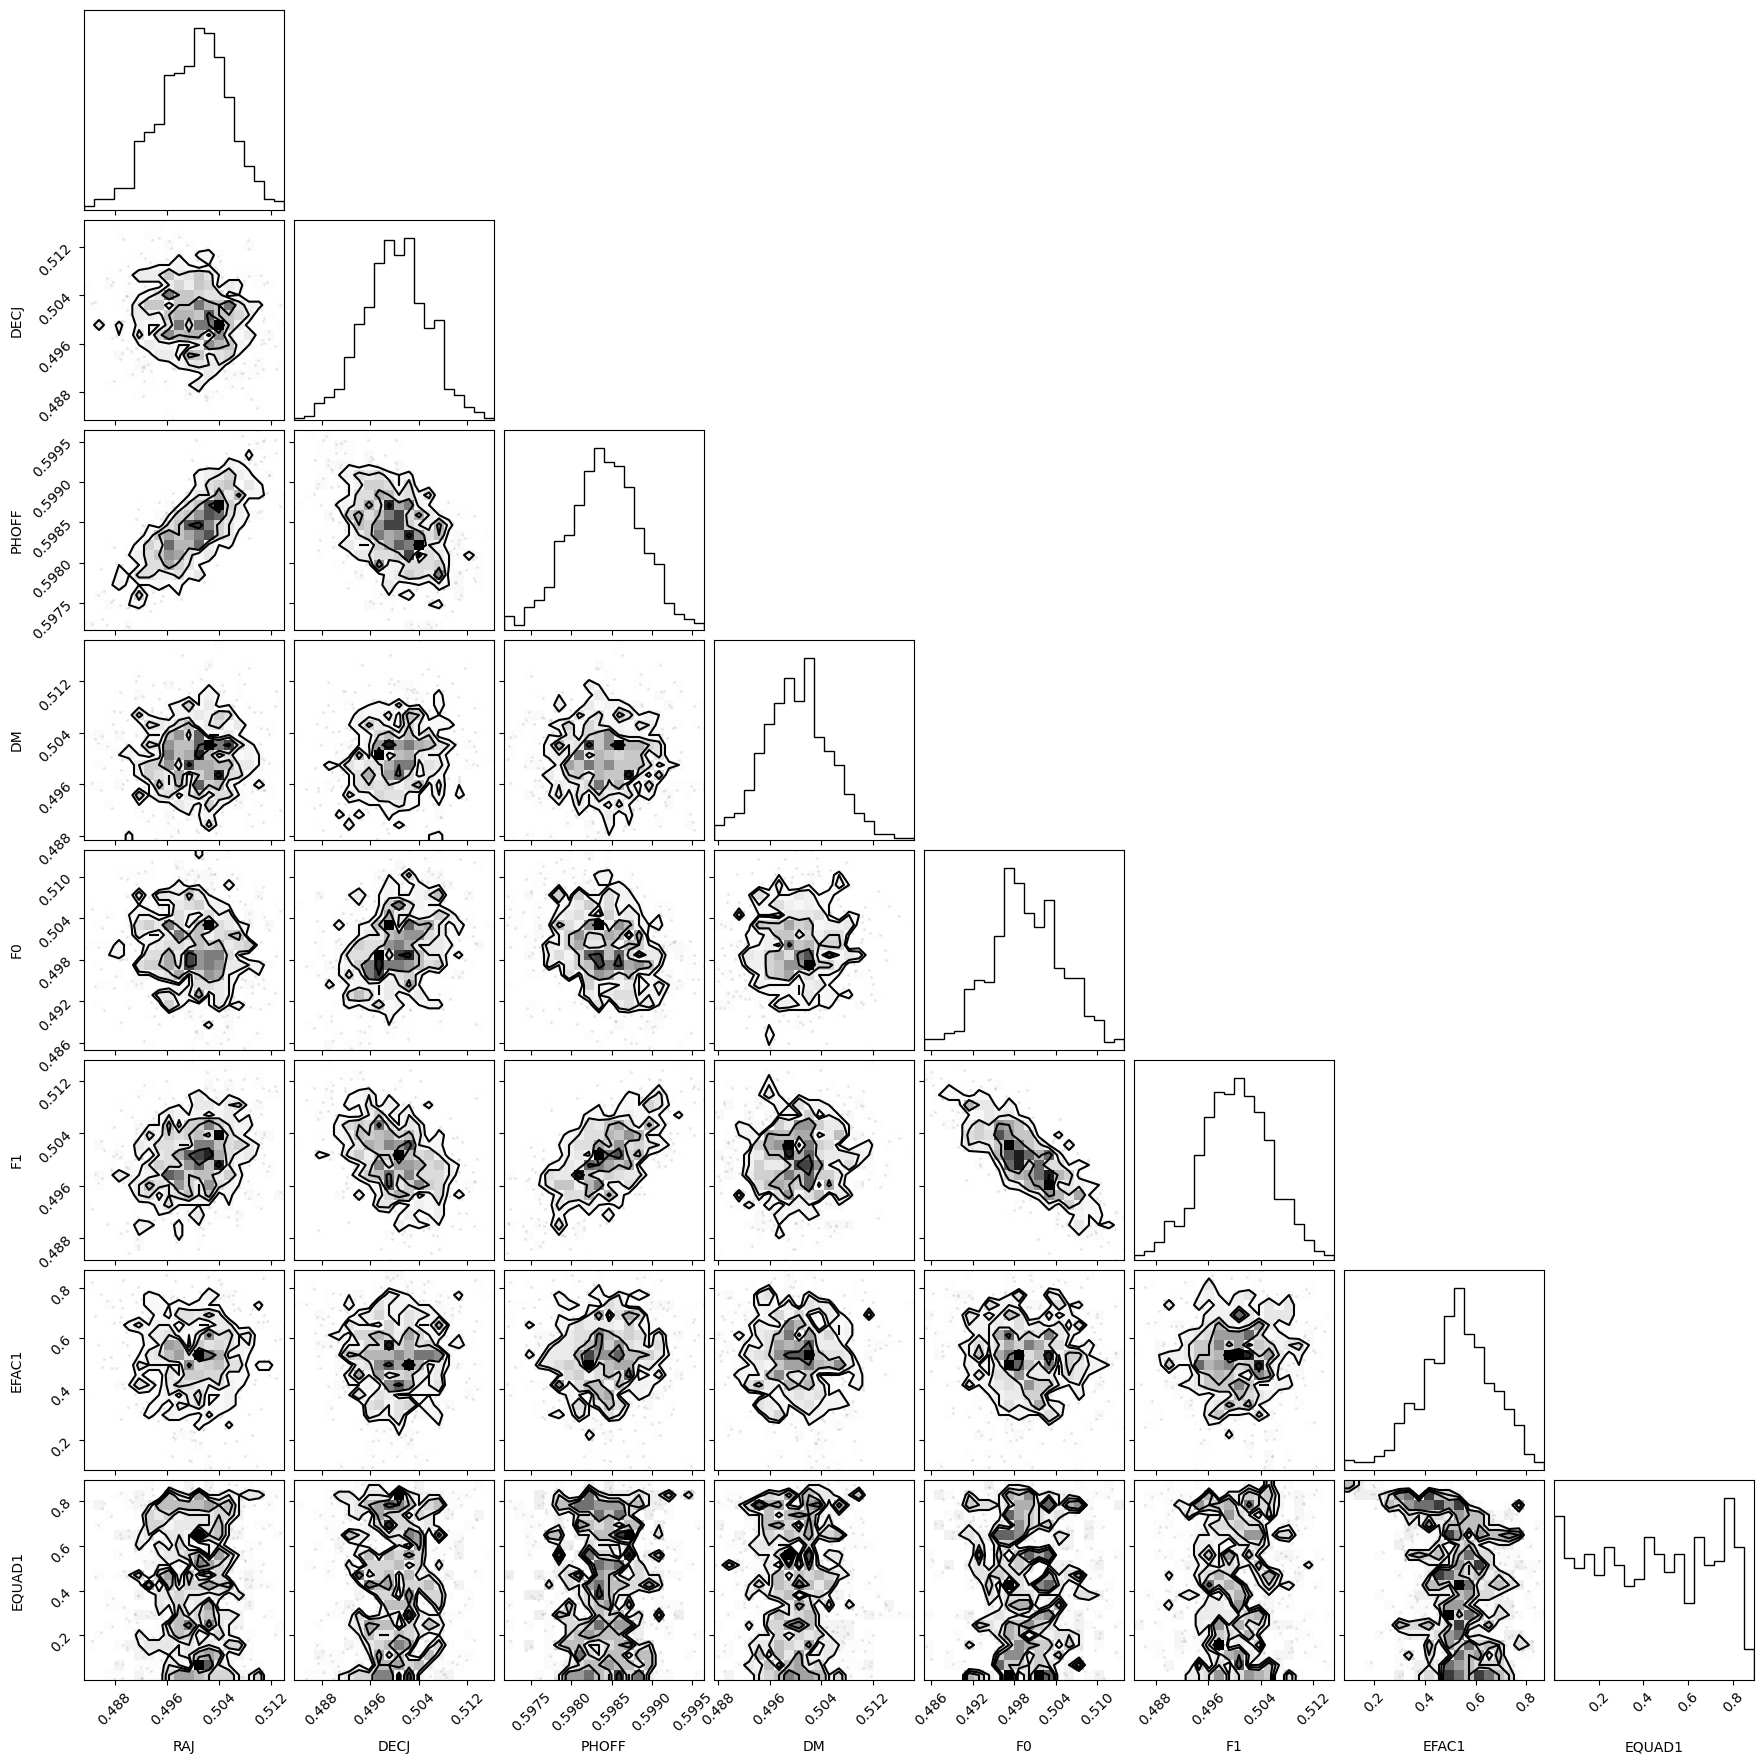

In [9]:
# Corner plot for the transformed variables. All parameters are within [0, 1].
corner.corner(samples_raw_untr, labels=spnta.param_names);

In [10]:
# Summary of 
params_med_raw = np.median(samples_raw, axis=0)
params_med = spnta.rescale_samples(params_med_raw)
params_std = np.std(samples, axis=0)
offsets = spnta.rescale_samples(spnta.param_offsets)

print(f"Param\t{'Unit':<15}{'Value':<33}Units")
print("-" * 77)
for pname, punit, pval, pstd in zip(
    spnta.param_names, spnta.param_units, params_med + offsets, params_std
):
    print(f"{pname}\t{punit:<15}{pval}\t+/-\t{pstd}")

Param	Unit           Value                            Units
-----------------------------------------------------------------------------
RAJ	hourangle      17.81466676807448	+/-	3.9143852792012104e-08
DECJ	deg            -20.358161606810878	+/-	9.456999099183758e-06
PHOFF	1              0.09841687347766809	+/-	0.00043540935026054316
DM	pc / cm3       224.11445866951746	+/-	0.035330375235105606
F0	Hz             61.48547655436926	+/-	1.8706761106009125e-11
F1	Hz / s         -1.1812955327676713e-15	+/-	1.4657876082126996e-18
EFAC1	1              1.0194340281240177	+/-	0.09732159396863112
EQUAD1	us             0.1558420775055554	+/-	4.392662733632732


In [11]:
spnta.save_results(result_dir, samples_raw)

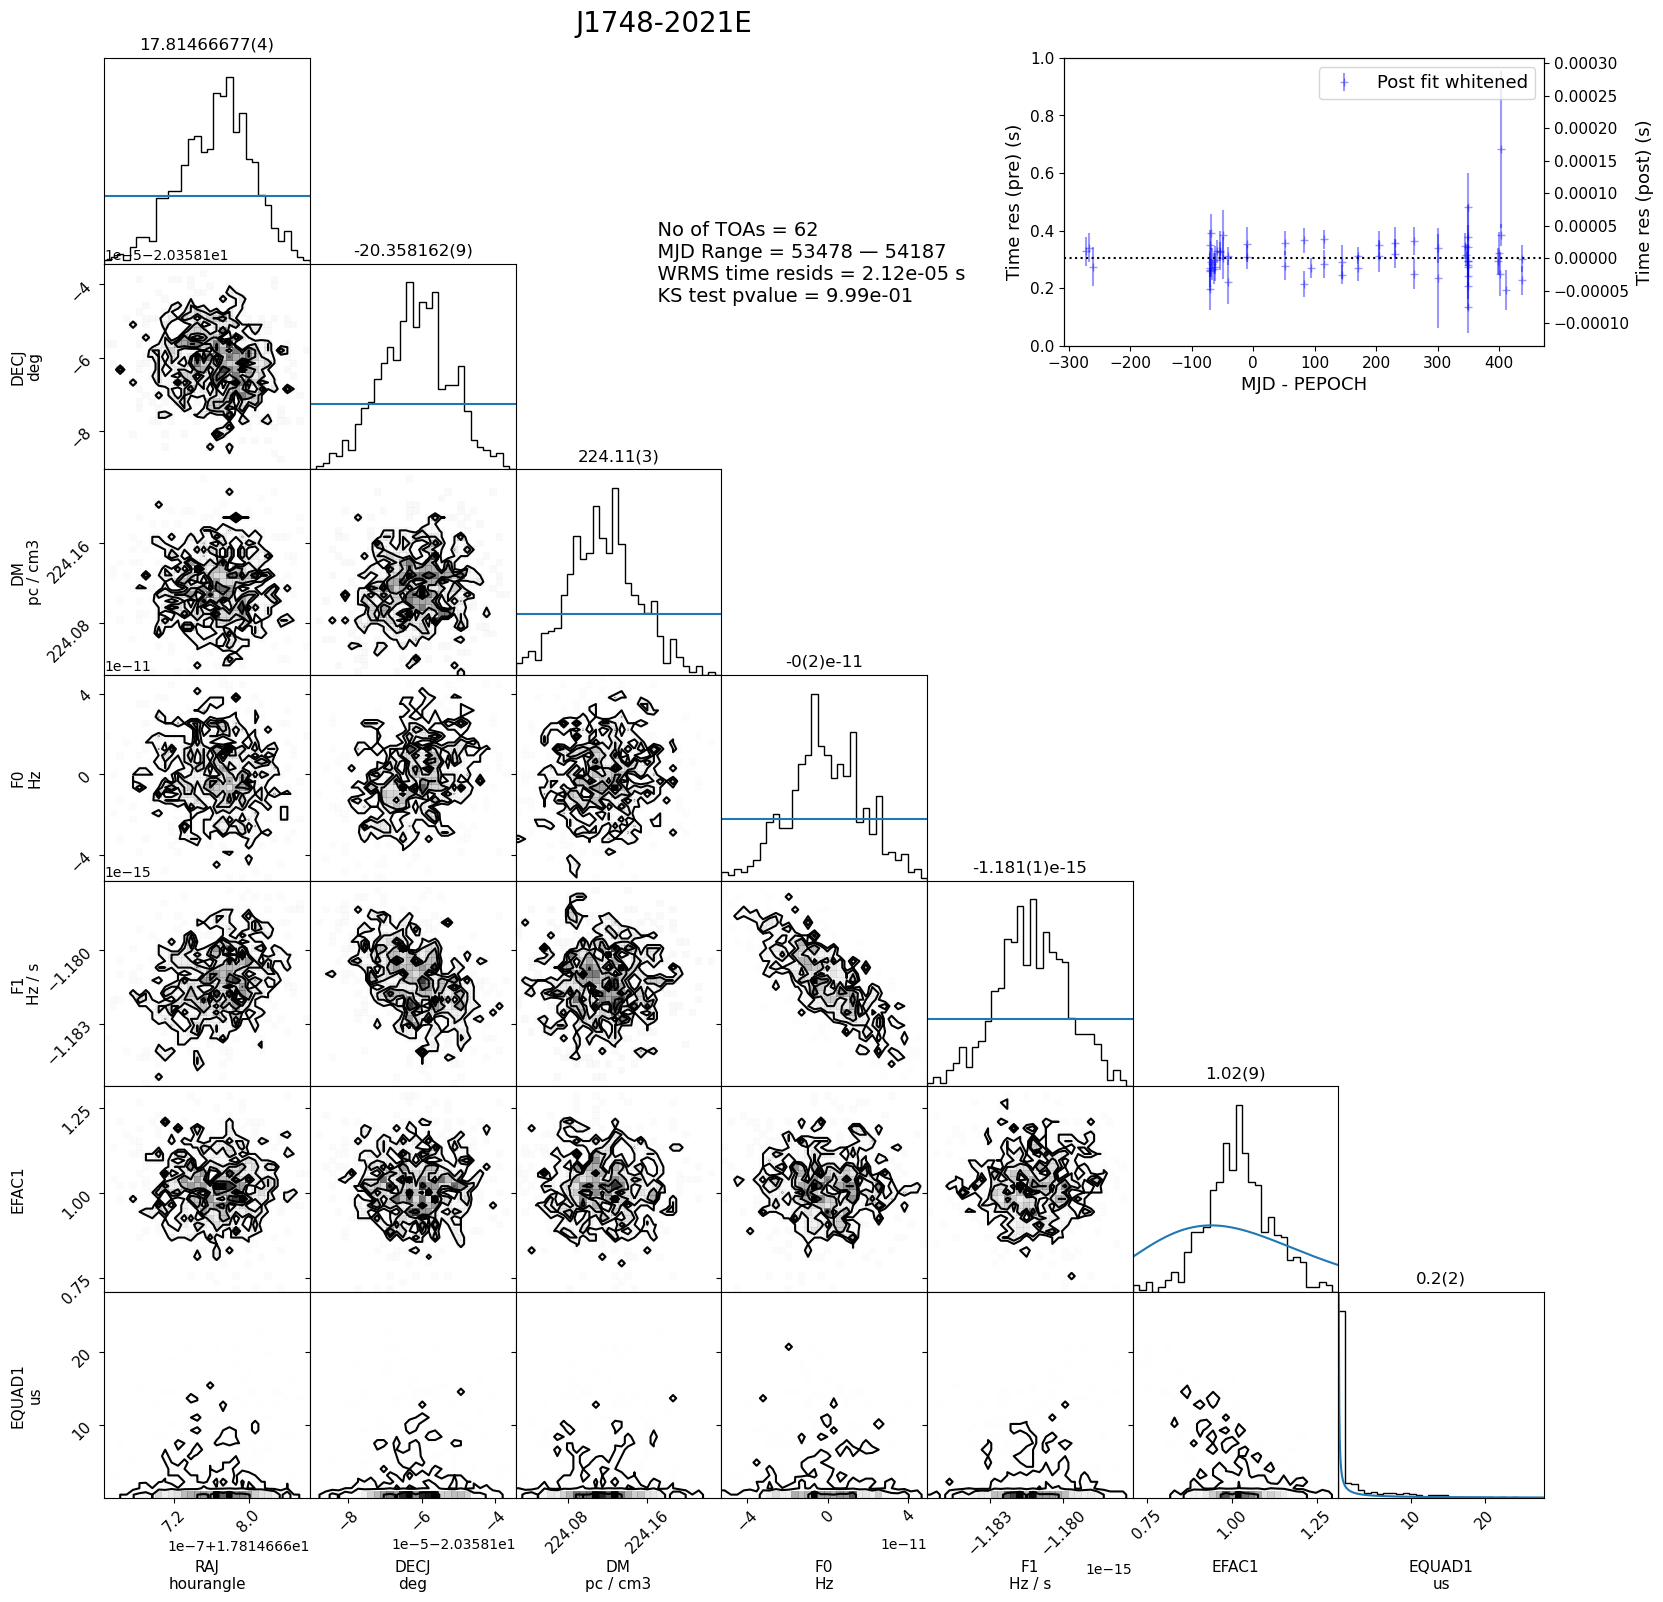

In [12]:
# Plot the un-transformed parameters and the whitened residuals.
pyvela_plot.plot(result_dir, plot_priors=True, labelpad=0)

In [13]:
# pyvela J0613-0200.InPTA.NB.par J0613-0200.InPTA.NB.tim -o J0613-0200.InPTA.NB_out -M -C 100 -f
# pyvela-plot J0613-0200.InPTA.NB_out --priors